# Reclustering Endothelial cells (res=0.2)

In [28]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse
import matplotlib.pyplot as plt

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'

NEW_OBJ = "endothelial"
NEW_OBJ_V = 'reclustered'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'sub' / NEW_OBJ / 'h5ad' / f'{NEW_OBJ}-{NEW_OBJ_V}.h5ad'

In [2]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

### Sub-clustering

In [16]:
cts = ["Endo"]
sub = comb[comb.obs["ann_lvl_3"].isin(cts)].copy()
sub


AnnData object with n_obs × n_vars = 95762 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'ann_lvl_3_colors', 'donor_colors', 'hvg', 'leiden_resolvi', 'leiden_resolvi_1.0_colors', 'log1p', 'nb_resolvi', '

In [17]:
print(sub.obs[["condition",'ann_lvl_3']].value_counts())

condition  ann_lvl_3
CF         Endo         62338
CTRL       Endo         23216
CF_ETI     Endo         10208
Name: count, dtype: int64


In [18]:
rsc.pp.neighbors(
    sub,
    use_rep="X_resolvi",   # change this to your actual key
    n_neighbors= 10,
    random_state=SEED_VALUE
)


In [19]:
rsc.tl.umap(
    sub,
    min_dist=0.3,
    random_state=SEED_VALUE
)


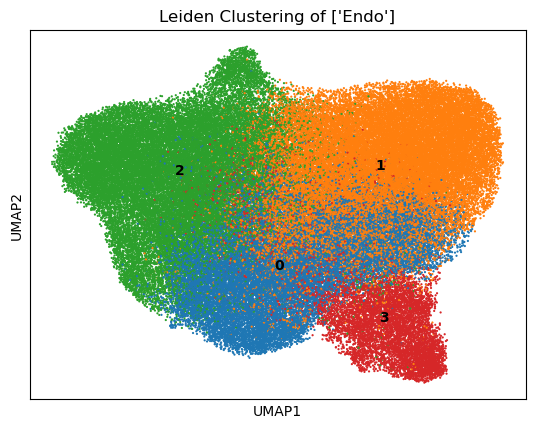

In [23]:
rsc.tl.leiden(sub, resolution=0.2, random_state=SEED_VALUE)

sc.pl.umap(
    sub, 
    color=["leiden"], 
    size=10, 
    legend_loc="on data", 
    frameon=True, 
    title=f"Leiden Clustering of {cts}"
)


Differential expression markers

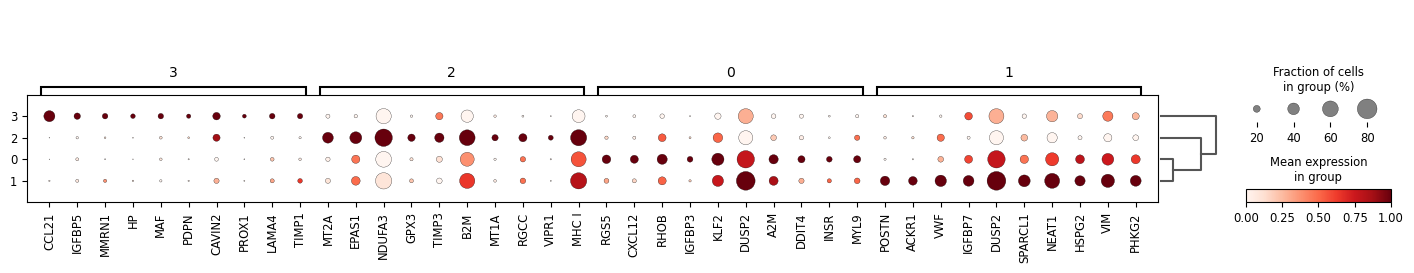

In [24]:
# get marker genes and dotplot

res_name = 'leiden'
layer_name = "resolvi_normalized"


rsc.tl.rank_genes_groups(
    sub, 
    groupby=res_name,
    method="wilcoxon",
)

sc.tl.dendrogram(
    sub, 
    groupby=res_name
)

# dotplot
dp = sc.pl.rank_genes_groups_dotplot(
    sub,
    groupby=res_name,
    #layer=layer_name,
    standard_scale="var",
    n_genes=10, # noramlly 5 
    show=False,
    return_fig=True,   # returns a DotPlot object
)

dp.show()


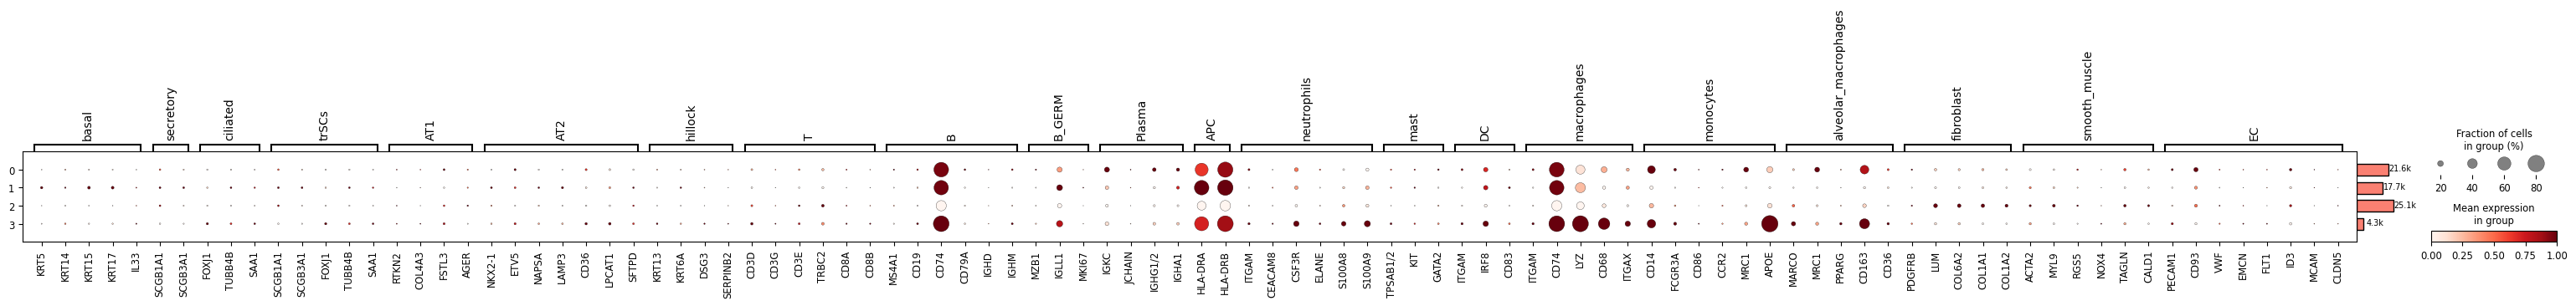

In [15]:
import json
# load canonical markers

all_markers_path = 'code/canonical_markers/all_markers.json'
with open(all_markers_path, 'r') as f:
    all_markers = json.load(f)
# NOTE: check python file, some genes are suposed to be low/not expressed in some cell types


dp = sc.pl.dotplot(
        sub, 
        all_markers,
        #layer=layer_name, 
        #use_raw=False,
        groupby=res_name, 
        standard_scale='var', 
        return_fig=True
    )
# adding cell counts to the dotplot
dp.add_totals().show()


Check locations

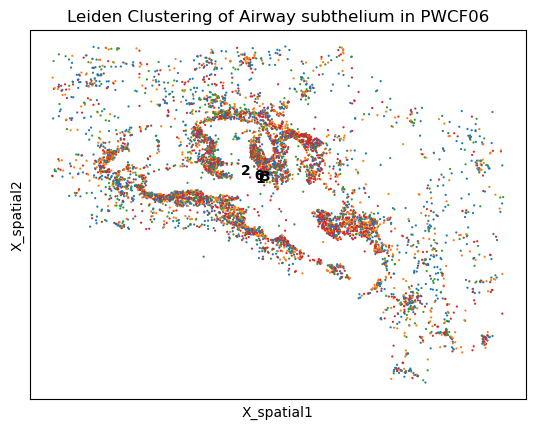

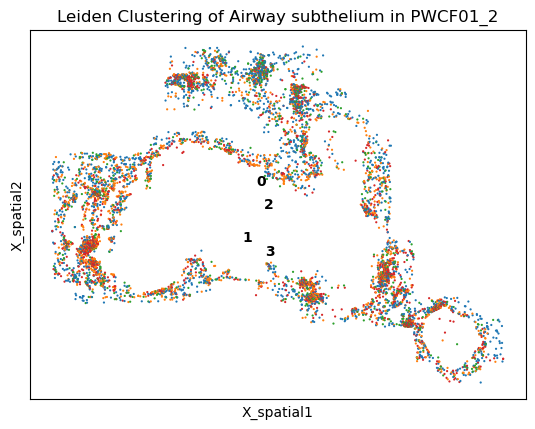

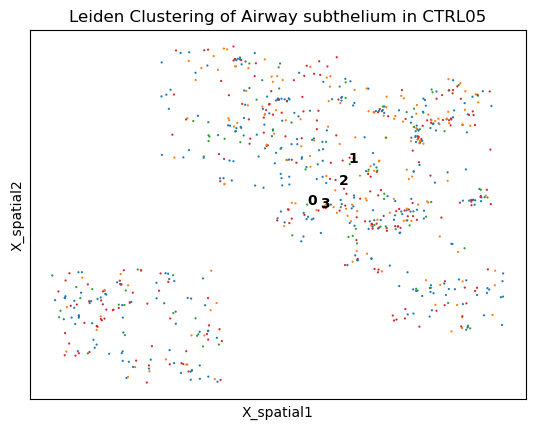

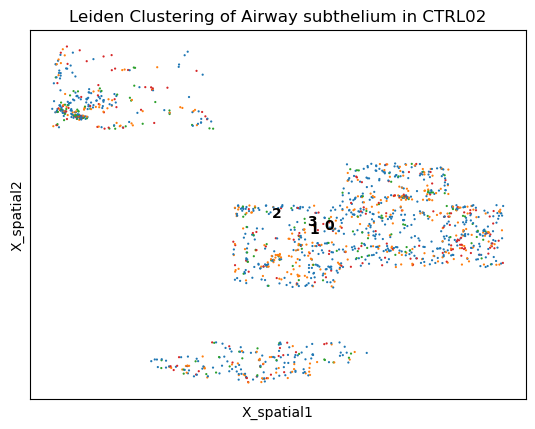

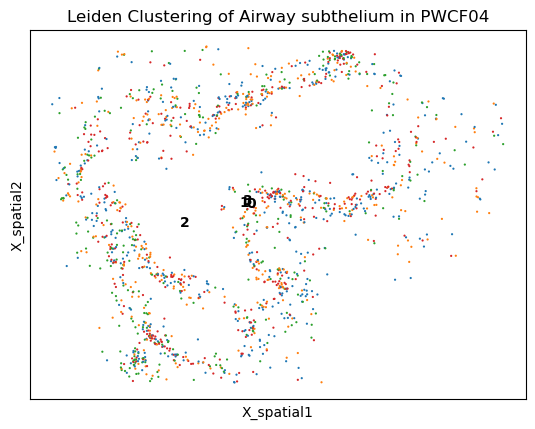

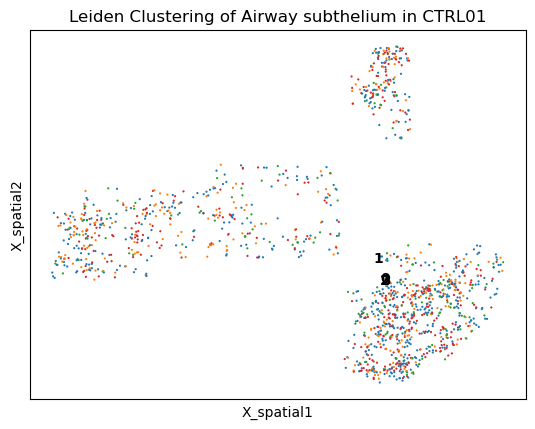

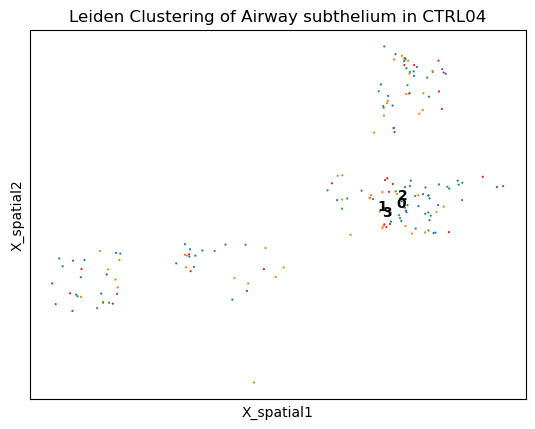

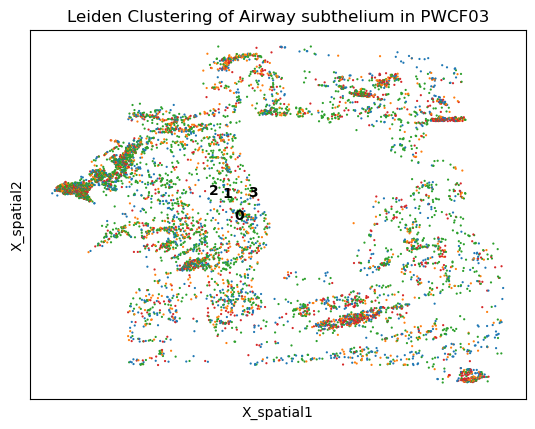

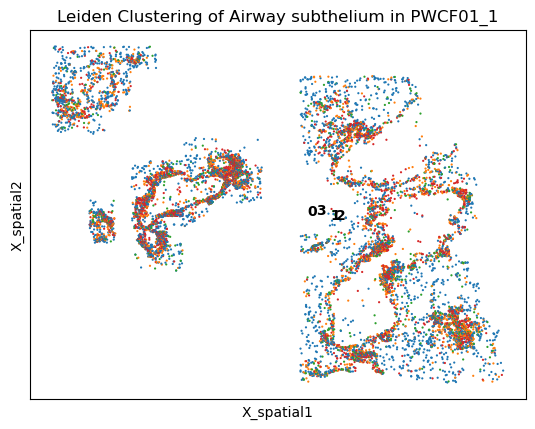

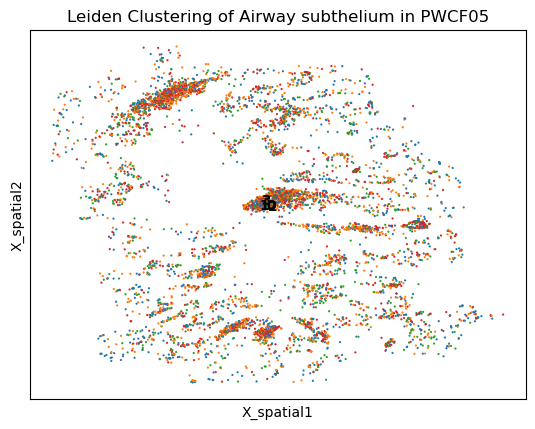

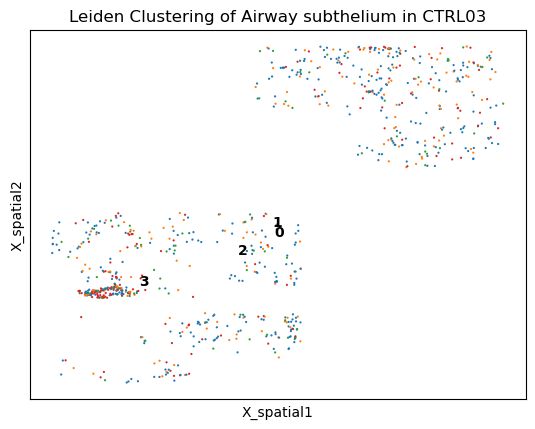

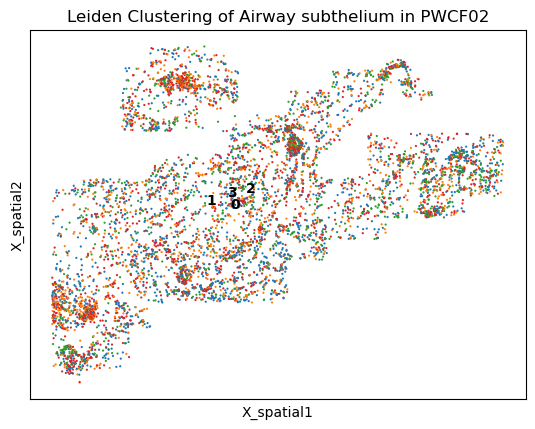

In [23]:
# print locations in PWCF01_1
samples = sub.obs['sample_name'].unique()

for sample in samples:
    mask = sub.obs['sample_name'] == sample

    sc.pl.embedding(
        sub[mask], 
        basis='X_spatial', 
        color='leiden', 
        #groups=['2'], # fibroblasts
        size=10, 
        legend_loc="on data", 
        frameon=True, 
        title=f"Leiden Clustering of Airway subthelium in {sample}"
    )

Name clusters

In [26]:
clusters_map = {
    "0": "EC",
    "1": "EC",
    "2": 'EC',
    "3": "lymEC",
    
}
CT_KEY = 'reclustered_ct'
CLUSTERS_KEY = 'leiden'
sub.obs[CT_KEY] = sub.obs[CLUSTERS_KEY].map(clusters_map).astype('category')

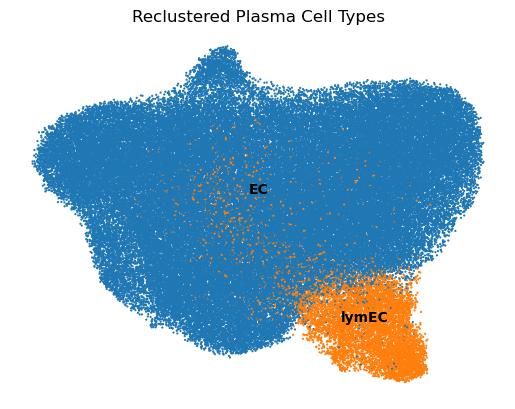

In [27]:
sc.pl.umap(
    sub, 
    color=[CT_KEY], 
    size=10, 
    legend_loc="on data", 
    frameon=False, 
    title="Reclustered Plasma Cell Types"
)

See how annotations changed

In [30]:
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

OLD_ANN_KEY = 'ann_lvl_3'
NEW_ANN_KEY = 'reclustered_ct'


# Keep only cells with both values
comparison = sub.obs[[OLD_ANN_KEY, NEW_ANN_KEY]].dropna().copy()

comparison[OLD_ANN_KEY] = comparison[OLD_ANN_KEY].astype(str)
comparison[NEW_ANN_KEY] = comparison[NEW_ANN_KEY].astype(str)

# -------------------------------------------------
# 1. Composition of every Leiden cluster
# -------------------------------------------------
counts = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
)

display(counts)

# Percentage composition within each Leiden cluster
percent_within_ann = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
    normalize="index",
) * 100

display(percent_within_ann.round(1))

reclustered_ct,EC,lymEC
ann_lvl_3,,
Endo,87303,8459


reclustered_ct,EC,lymEC
ann_lvl_3,,
Endo,91.2,8.8


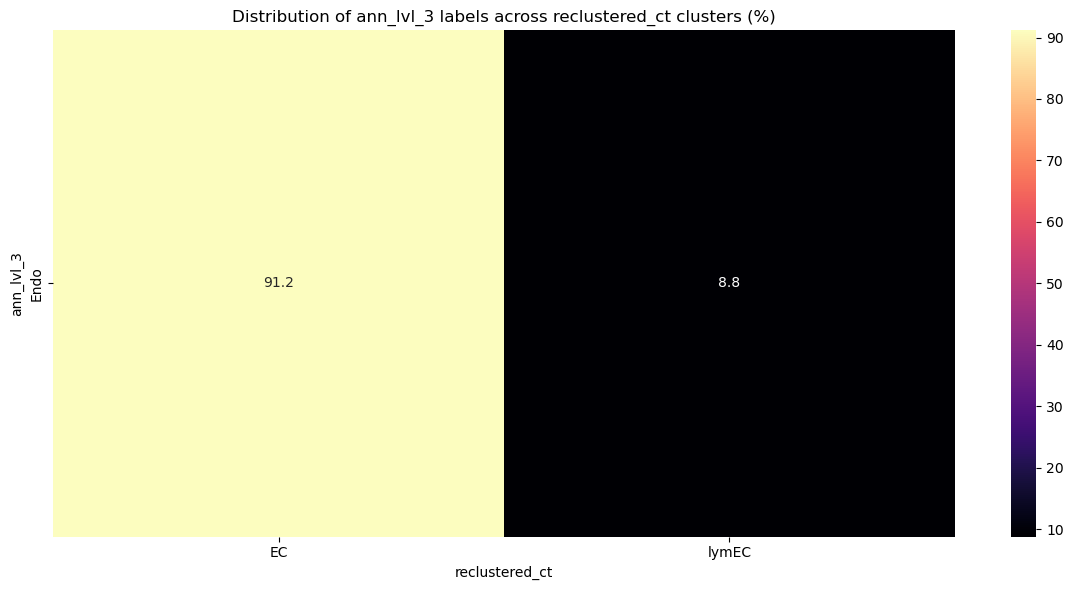

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(percent_within_ann, cmap="magma", annot=True, fmt=".1f")
plt.xlabel(NEW_ANN_KEY)
plt.ylabel(OLD_ANN_KEY)
plt.title(f"Distribution of {OLD_ANN_KEY} labels across {NEW_ANN_KEY} clusters (%)")
plt.tight_layout()
plt.show()

Save annotated object

In [32]:
# create the parent folder of the new object path if it doesn't exist
NEW_OBJ_PATH.parent.mkdir(parents=True, exist_ok=True)

In [33]:
sub.write_h5ad(NEW_OBJ_PATH)